# Running this tutorial

This notebook is designed to run in Google Colab during the workshop. Before starting, save your own editable copy using **File -> Save a copy in Drive**.

All required packages can be installed automatically using the setup cell below. The same notebook can also run locally in a standard Python environment, provided the required packages are installed.

In [1]:
# Install required packages for the tutorial
!pip -q install pymatgen dimod dwave-neal networkx matplotlib ase

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621


DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.9/bin/python3.9 -m pip install --upgrade pip


In [2]:
import importlib.metadata
import itertools

import ase
import dimod
import matplotlib.pyplot as plt
import neal
import networkx as nx
import numpy as np
import pymatgen
from ase.visualize.plot import plot_atoms
from pymatgen.core.structure import Structure
from pymatgen.io.ase import AseAtomsAdaptor

np.set_printoptions(precision=3, suppress=True)


def package_version(package_name, module=None):
    if module is not None and hasattr(module, "__version__"):
        return module.__version__
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return "version unavailable"


print("All imports successful.")
print("numpy version:", package_version("numpy", np))
print("networkx version:", package_version("networkx", nx))
print("matplotlib version:", package_version("matplotlib"))
print("dimod version:", package_version("dimod", dimod))
print("dwave-neal version:", package_version("dwave-neal", neal))
print("pymatgen version:", package_version("pymatgen", pymatgen))
print("ase version:", package_version("ase", ase))

All imports successful.
numpy version: 1.22.4
networkx version: 2.8.2
matplotlib version: 3.5.2
dimod version: 0.11.1
dwave-neal version: 0.5.9
pymatgen version: 2022.5.26
ase version: 3.22.1


The notebook uses the classical simulated annealing sampler `neal`. No quantum hardware access is required. The D-Wave workflow section is optional.

## Recommended workflow during the workshop

1. Run the setup cells.
2. Run cells sequentially from top to bottom.
3. Try the exercises before looking at the hints/solutions.
4. Modify parameters and rerun cells to explore behaviour.

# QUBO tutorial: from graph problems to vacancies in graphene

This tutorial shows how to map a simple materials-science configurational problem onto a quadratic unconstrained binary optimisation (QUBO) model.

The running materials example is a graphene sheet with vacancies. The physical model is intentionally simple: it uses a nearest-neighbour graph and a bond-counting objective. The purpose is to make the QUBO mapping transparent, not to produce quantitatively accurate vacancy formation energies.

The workflow is:

1. Choose binary variables.
2. Write the objective and constraints in terms of those variables.
3. Build a QUBO matrix or dictionary.
4. Sample low-energy bitstrings.
5. Interpret the bitstrings as candidate material configurations.


## Helper functions

Run this helper cell once, then feel free to collapse it.

In [3]:
def qubo_energy(x, Q):
    """Return x.T Q x for an upper-triangular QUBO matrix."""
    x = np.asarray(x, dtype=float)
    Q = np.asarray(Q, dtype=float)
    return float(x @ Q @ x)


def add_fixed_count_constraint(Q, k, gamma):
    """Add gamma * (sum_i x_i - k)^2 to an upper-triangular QUBO matrix.

    The constant gamma * k**2 is returned separately because it does not affect
    which bitstring minimises the QUBO.
    """
    Q = np.array(Q, dtype=float, copy=True)
    n = Q.shape[0]

    for i in range(n):
        Q[i, i] += gamma * (1 - 2 * k)

    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2 * gamma

    offset = gamma * k**2
    return Q, offset


def sample_to_vector(sample, variables):
    """Convert a dimod/neal sample dictionary into a vector in a fixed order."""
    return np.array([sample[v] for v in variables], dtype=int)


def nonzero_qubo_terms(Q):
    """List non-zero terms of an upper-triangular QUBO matrix."""
    Q = np.asarray(Q)
    terms = []
    for i in range(Q.shape[0]):
        for j in range(i, Q.shape[1]):
            if not np.isclose(Q[i, j], 0.0):
                terms.append((i, j, Q[i, j]))
    return terms


def neighbouring_selected_pairs(x, A):
    """Count selected nearest-neighbour pairs for a binary vector x."""
    x = np.asarray(x, dtype=int)
    A = np.asarray(A, dtype=int)
    return int(
        sum(
            1
            for i in range(A.shape[0])
            for j in range(i + 1, A.shape[1])
            if A[i, j] and x[i] == 1 and x[j] == 1
        )
    )


def remove_sites_by_index(structure, site_indices):
    """Return a copy of a pymatgen structure with selected sites removed."""
    structure_with_removed_sites = structure.copy()
    structure_with_removed_sites.remove_sites(sorted(site_indices, reverse=True))
    return structure_with_removed_sites


def plot_structure(
    structure,
    supercell=(3, 3, 1),
    vacancy_indices=None,
    title=None,
    show_cell=True,
    ax=None,
):
    """Plot a pymatgen structure inline, optionally repeated and with vacancies marked.

    The repetition is for visualisation only; the input structure is not modified.
    Vacancy indices refer to sites in the input structure before repetition.
    """
    repeat = tuple(supercell)
    ase_atoms = AseAtomsAdaptor.get_atoms(structure.copy())
    display_atoms = ase_atoms.repeat(repeat)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    plot_atoms(
        display_atoms,
        ax=ax,
        radii=0.32,
        rotation="0x,0y,0z",
        show_unit_cell=2 if show_cell else 0,
    )

    if vacancy_indices is not None:
        vacancy_indices = list(vacancy_indices)
        base_positions = ase_atoms.get_positions()
        base_cell = ase_atoms.get_cell().array
        vacancy_positions = []

        for a in range(repeat[0]):
            for b in range(repeat[1]):
                for c in range(repeat[2]):
                    translation = a * base_cell[0] + b * base_cell[1] + c * base_cell[2]
                    for index in vacancy_indices:
                        vacancy_positions.append(base_positions[index] + translation)

        if vacancy_positions:
            vacancy_positions = np.asarray(vacancy_positions)
            ax.scatter(
                vacancy_positions[:, 0],
                vacancy_positions[:, 1],
                s=190,
                facecolors="none",
                edgecolors="crimson",
                linewidths=2.2,
                zorder=10,
                label="selected vacancy site",
            )
            ax.scatter(
                vacancy_positions[:, 0],
                vacancy_positions[:, 1],
                s=70,
                marker="x",
                c="crimson",
                linewidths=1.8,
                zorder=11,
            )
            ax.legend(loc="upper right", frameon=False)

    ax.set_aspect("equal")
    ax.set_axis_off()
    if title is not None:
        ax.set_title(title)
    plt.tight_layout()
    return fig, ax


## 1. QUBO theoretical introduction

A QUBO uses binary variables

$$
x_i \in \{0, 1\}.
$$

A configuration is the vector

$$
\mathbf{x} = (x_0, x_1, \ldots, x_{n-1}).
$$

The QUBO objective is

$$
E(\mathbf{x}) = \mathbf{x}^T Q \mathbf{x}
= \sum_i Q_{i,i} x_i + \sum_i \sum_{j>i} Q_{i,j} x_i x_j.
$$

The diagonal entries $Q_{i,i}$ are linear terms because $x_i^2 = x_i$ for binary variables. The off-diagonal entries $Q_{i,j}$ are pair interactions between binary variables.

A related Ising model uses spin variables $s_i \in \{-1, +1\}$. The two encodings are connected by

$$
s_i = 2x_i - 1, \qquad x_i = \frac{s_i + 1}{2}.
$$

In this notebook we work directly in QUBO form with binary variables. We use:

- $Q$ for the QUBO matrix or dictionary.
- $A$ for an adjacency matrix.
- $k$ for the required number of selected sites.
- $x_i = 1$ to mean that item/site $i$ is selected. In the graphene section, selected means vacant.


## Exercise 1: Expand a fixed-count constraint

**Motivation.** Fixed-count constraints appear throughout QUBO modelling, including balanced graph partitions and fixed-composition material configurations.

**Task.** For four binary variables and $k = 2$, expand

$$
\left(\sum_{i=0}^{3} x_i - k\right)^2.
$$

Identify:

- the constant term,
- the linear terms,
- the quadratic terms,
- why this constraint creates pairwise couplings.

**Discussion.** How large should the penalty weight be relative to the objective? What can go wrong if it is too small?


### Solution / hint

For four variables and $k=2$,

$$
(x_0+x_1+x_2+x_3-2)^2
= \sum_i x_i^2 + 2\sum_{i<j}x_i x_j - 4\sum_i x_i + 4.
$$

Because the variables are binary, $x_i^2=x_i$, so this becomes

$$
-3\sum_i x_i + 2\sum_{i<j}x_i x_j + 4.
$$

The constant is $4$, each linear coefficient is $-3$, and each pairwise quadratic coefficient is $2$. The pairwise couplings appear because squaring the sum creates cross terms $x_i x_j$.


## 2. A simple graph partitioning example

Consider a graph whose nodes represent people and whose edges represent friendships. We want to divide the graph into two groups while cutting as few edges as possible.

Let

$$
x_i =
\begin{cases}
0 & \text{node } i \text{ is in group 0},\\
1 & \text{node } i \text{ is in group 1}.
\end{cases}
$$

For an edge $(i,j)$, the expression

$$
x_i + x_j - 2x_i x_j
$$

is 1 when the two endpoints are in different groups and 0 when they are in the same group. Therefore, minimising

$$
\sum_{(i,j) \in E} \left(x_i + x_j - 2x_i x_j\right)
$$

minimises the number of cut edges. Without a balance constraint, the trivial all-zero or all-one solution cuts no edges. We will add a constraint requiring exactly $k = n/2$ nodes in group 1.


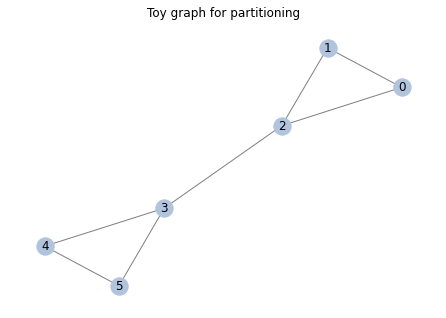

Adjacency matrix A:
[[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 0 0]
 [0 0 1 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]


In [4]:
# A deterministic toy graph, instead of a random one, makes the tutorial reproducible.
G = nx.Graph()
G.add_nodes_from(range(6))
G.add_edges_from([(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (3, 5), (4, 5)])

pos = nx.spring_layout(G, seed=4)
nx.draw(G, pos=pos, with_labels=True, node_color="lightsteelblue", edge_color="gray")
plt.title("Toy graph for partitioning")
plt.show()

A_graph = nx.to_numpy_array(G, nodelist=range(6), dtype=int)
print("Adjacency matrix A:")
print(A_graph.astype(int))


In [5]:
n = G.number_of_nodes()
Q_partition = np.zeros((n, n))

for i, j in G.edges:
    Q_partition[i, i] += 1
    Q_partition[j, j] += 1
    Q_partition[i, j] += -2

print("Non-zero QUBO terms for the cut objective:")
print(nonzero_qubo_terms(Q_partition))

for bits in itertools.product([0, 1], repeat=n):
    energy = qubo_energy(bits, Q_partition)
    if energy == 0:
        print("A zero-cut, unconstrained solution:", bits)
        break


Non-zero QUBO terms for the cut objective:
[(0, 0, 2.0), (0, 1, -2.0), (0, 2, -2.0), (1, 1, 2.0), (1, 2, -2.0), (2, 2, 3.0), (2, 3, -2.0), (3, 3, 3.0), (3, 4, -2.0), (3, 5, -2.0), (4, 4, 2.0), (4, 5, -2.0), (5, 5, 2.0)]
A zero-cut, unconstrained solution: (0, 0, 0, 0, 0, 0)


In [6]:
k = n // 2
constraint_strength = 4.0
Q_partition_balanced, partition_offset = add_fixed_count_constraint(
    Q_partition, k=k, gamma=constraint_strength
)

sampler = neal.SimulatedAnnealingSampler()
sampleset_partition = sampler.sample_qubo(Q_partition_balanced, num_reads=200, seed=11)

best_partition = sampleset_partition.first.sample
x_partition = sample_to_vector(best_partition, range(n))
cut_edges = [(i, j) for i, j in G.edges if x_partition[i] != x_partition[j]]

print("Best bitstring:", x_partition.tolist())
print("Number of nodes in group 1:", int(x_partition.sum()))
print("Group 0:", np.where(x_partition == 0)[0].tolist())
print("Group 1:", np.where(x_partition == 1)[0].tolist())
print("Cut edges:", cut_edges)
print("Cut size:", len(cut_edges))
assert x_partition.sum() == k


Best bitstring: [1, 1, 1, 0, 0, 0]
Number of nodes in group 1: 3
Group 0: [3, 4, 5]
Group 1: [0, 1, 2]
Cut edges: [(2, 3)]
Cut size: 1


The solution bitstring is not just a mathematical object: each bit has an interpretation. Here, `0` and `1` label the two graph partitions. Later, the same idea will be used for material sites, where `1` labels a vacancy.


## Exercise 2: Interpret a bitstring on a graph

**Motivation.** A QUBO solution only becomes useful after each bit is mapped back to the original problem.

**Task.** Using the same graph `G`, interpret the bitstring

```python
x_ex2 = [1, 0, 1, 0, 1, 0]
```

Answer:

- Which nodes are selected?
- Which graph edges connect selected nodes?
- How would the graph-partitioning energy change if one bit is flipped?
- What would the same answer mean physically if selected nodes represented vacancies?

**Discussion.** Does the interpretation of a bitstring belong to the QUBO matrix, or to the modelling convention chosen before building it?


In [7]:
# Starter code for Exercise 2.
x_ex2 = np.array([1, 0, 1, 0, 1, 0])
selected_ex2 = np.where(x_ex2 == 1)[0].tolist()
edges_between_selected_ex2 = [
    (i, j) for i, j in G.edges if x_ex2[i] == 1 and x_ex2[j] == 1
]

print("Selected nodes:", selected_ex2)
print("Edges connecting selected nodes:", edges_between_selected_ex2)


Selected nodes: [0, 2, 4]
Edges connecting selected nodes: [(0, 2)]


### Solution / hint

The selected nodes are the indices where the bitstring contains `1`. For the graph-partitioning objective, flipping one bit can either increase or decrease the number of edges cut between the two groups. The change depends only on the flipped node and its neighbours.

If the same bits represented vacancies, the selected nodes would be vacancy sites. Edges connecting selected nodes would be neighbouring vacancy pairs.


In [8]:
# One way to quantify the effect of flipping each bit for the partitioning QUBO.
base_energy_ex2 = qubo_energy(x_ex2, Q_partition)
print("Base graph-partitioning objective:", base_energy_ex2)

for flip_index in range(len(x_ex2)):
    x_flipped = x_ex2.copy()
    x_flipped[flip_index] = 1 - x_flipped[flip_index]
    flipped_energy = qubo_energy(x_flipped, Q_partition)
    print(
        f"flip node {flip_index}: energy {flipped_energy:.0f}, "
        f"change {flipped_energy - base_energy_ex2:+.0f}"
    )


Base graph-partitioning objective: 5.0
flip node 0: energy 5, change +0
flip node 1: energy 3, change -2
flip node 2: energy 4, change -1
flip node 3: energy 4, change -1
flip node 4: energy 3, change -2
flip node 5: energy 5, change +0


## 3. Constraints in QUBO

QUBO solvers minimise an unconstrained objective, so constraints are usually added as penalty terms.

To enforce exactly $k$ selected variables, use

$$
\gamma \left(\sum_i x_i - k\right)^2,
$$

where $\gamma > 0$ controls the penalty strength. Expanding the square gives

$$
\gamma \left(\sum_i x_i - k\right)^2
= \gamma \left[
\sum_i x_i^2
+ 2\sum_i\sum_{j>i} x_i x_j
- 2k\sum_i x_i
+ k^2
\right].
$$

Using $x_i^2 = x_i$,

$$
= \gamma \left[
(1 - 2k)\sum_i x_i
+ 2\sum_i\sum_{j>i} x_i x_j
+ k^2
\right].
$$

The constant $\gamma k^2$ shifts all energies by the same amount, so it can be ignored during sampling. The QUBO coefficients receive:

$$
Q_{i,i} \leftarrow Q_{i,i} + \gamma(1 - 2k),
$$

$$
Q_{i,j} \leftarrow Q_{i,j} + 2\gamma \quad \text{for } i<j.
$$


In [9]:
# Minimal sanity check for the fixed-count penalty.
n_constraint = 5
k_constraint = 2
gamma_constraint = 3.0
Q_empty = np.zeros((n_constraint, n_constraint))
Q_fixed, offset_fixed = add_fixed_count_constraint(Q_empty, k=k_constraint, gamma=gamma_constraint)

for count in range(n_constraint + 1):
    bits = np.array([1] * count + [0] * (n_constraint - count))
    penalty_without_offset = qubo_energy(bits, Q_fixed)
    penalty_with_offset = penalty_without_offset + offset_fixed
    print(
        f"selected={count}: penalty={penalty_with_offset:.1f}, "
        f"expected={gamma_constraint * (count - k_constraint) ** 2:.1f}"
    )


selected=0: penalty=12.0, expected=12.0
selected=1: penalty=3.0, expected=3.0
selected=2: penalty=0.0, expected=0.0
selected=3: penalty=3.0, expected=3.0
selected=4: penalty=12.0, expected=12.0
selected=5: penalty=27.0, expected=27.0


## Exercise 3: Change the number of selected sites

**Motivation.** The fixed-count penalty is reusable: changing the target count should only require changing `k`, not rebuilding the whole tutorial.

**Task.** Modify the fixed-count QUBO so that exactly 3 sites are selected instead of the current value. Use the existing helper functions where possible.

Include checks that:

- print the selected sites,
- print the number selected,
- assert that the selected count is 3.

**Discussion.** Which QUBO coefficients change when `k` changes? Do the pairwise coefficients depend on `k`?


In [10]:
# Starter code for Exercise 3.
k_ex3 = 3
n_ex3 = n_constraint
Q_ex3_base = np.zeros((n_ex3, n_ex3))

# TODO in the workshop: add a fixed-count constraint with k_ex3,
# sample it with neal, and check that exactly 3 variables are selected.
print("Exercise 3 target selected count:", k_ex3)


Exercise 3 target selected count: 3


### Solution / hint

Only the diagonal contribution from the fixed-count penalty depends on `k`: $\gamma(1-2k)$. The off-diagonal contribution is $2\gamma$ for every pair, independent of `k`.


In [11]:
Q_ex3, offset_ex3 = add_fixed_count_constraint(Q_ex3_base, k=k_ex3, gamma=gamma_constraint)
sampleset_ex3 = neal.SimulatedAnnealingSampler().sample_qubo(Q_ex3, num_reads=100, seed=31)
x_ex3 = sample_to_vector(sampleset_ex3.first.sample, range(n_ex3))
selected_sites_ex3 = np.where(x_ex3 == 1)[0].tolist()

print("Selected sites:", selected_sites_ex3)
print("Number selected:", int(x_ex3.sum()))
print("Energy with offset:", sampleset_ex3.first.energy + offset_ex3)
assert x_ex3.sum() == 3


Selected sites: [1, 3, 4]
Number selected: 3
Energy with offset: 0.0


## 4. Solvers: `neal` and quantum annealing workflows

`neal` is a classical simulated annealing sampler from the D-Wave Ocean ecosystem. It samples low-energy binary configurations by thermal updates. It is useful for local development, debugging QUBO coefficients, and producing baseline results.

A quantum annealer uses physical qubits and couplers to sample from an Ising or QUBO-like energy landscape. In practice, running on hardware also introduces embedding, chain strength, hardware topology, calibration, and queue/access considerations.

The conceptual workflow is similar:

```python
# Classical simulated annealing, runnable locally
import neal
sampler = neal.SimulatedAnnealingSampler()
sampleset = sampler.sample_qubo(Q, num_reads=100)

# Quantum annealing workflow, requires D-Wave access and credentials
# from dwave.system import DWaveSampler, EmbeddingComposite
# sampler = EmbeddingComposite(DWaveSampler())
# sampleset = sampler.sample_qubo(Q, num_reads=1000, chain_strength=...)
```

In the rest of this notebook we use `neal` so that the examples run without hardware access.


In [12]:
# A tiny QUBO to show the local sampler interface.
Q_tiny = {
    ("x0", "x0"): -1.0,
    ("x1", "x1"): -1.0,
    ("x0", "x1"): 2.0,
}

sampleset_tiny = neal.SimulatedAnnealingSampler().sample_qubo(Q_tiny, num_reads=20, seed=5)
print(sampleset_tiny)


   x0 x1 energy num_oc.
0   1  0   -1.0       1
1   0  1   -1.0       1
2   0  1   -1.0       1
3   1  0   -1.0       1
4   0  1   -1.0       1
5   1  0   -1.0       1
6   1  0   -1.0       1
7   0  1   -1.0       1
8   0  1   -1.0       1
9   0  1   -1.0       1
10  0  1   -1.0       1
11  0  1   -1.0       1
12  1  0   -1.0       1
13  0  1   -1.0       1
14  0  1   -1.0       1
15  1  0   -1.0       1
16  0  1   -1.0       1
17  1  0   -1.0       1
18  1  0   -1.0       1
19  1  0   -1.0       1
['BINARY', 20 rows, 20 samples, 2 variables]


## Exercise 6: Compare sampler behaviour

**Motivation.** A sampler returns samples, not a proof of optimality. Repeating the same QUBO with different sampler settings helps reveal whether the landscape has one dominant low-energy solution or many near-degenerate ones.

**Task.** Run the same QUBO multiple times while changing:

- `num_reads`,
- annealing-related parameters supported by `neal`, such as `num_sweeps`.

Compare:

- best energy,
- number of distinct samples,
- frequency of the best sample,
- whether the sampler appears to find one dominant solution or many near-degenerate solutions.

**Discussion.** How would this diagnostic change if the QUBO were sent to quantum annealing hardware?


In [13]:
# Starter/solution code for Exercise 6.
experiments_ex6 = [
    {"num_reads": 20, "num_sweeps": 100, "seed": 41},
    {"num_reads": 100, "num_sweeps": 100, "seed": 42},
    {"num_reads": 100, "num_sweeps": 1000, "seed": 43},
]

print(f"{'num_reads':>10} {'num_sweeps':>11} {'best_E':>8} {'distinct':>9} {'best_freq':>10}")
for config in experiments_ex6:
    ss_ex6 = neal.SimulatedAnnealingSampler().sample_qubo(Q_partition_balanced, **config)
    aggregated_ex6 = ss_ex6.aggregate()
    print(
        f"{config['num_reads']:10d} {config['num_sweeps']:11d} "
        f"{ss_ex6.first.energy:8.1f} {len(aggregated_ex6):9d} "
        f"{ss_ex6.first.num_occurrences:10d}"
    )


 num_reads  num_sweeps   best_E  distinct  best_freq
        20         100    -35.0         5          1
       100         100    -35.0        16          1
       100        1000    -35.0         2          1


### Solution / hint

For this small graph, many balanced partitions can be sampled quickly. Increasing `num_reads` generally gives a better estimate of the distribution of low-energy samples, while increasing `num_sweeps` gives each read more update steps. Near-degenerate problems may show several distinct samples with the same or similar energy.


## 5. Vacancies in graphene

We now move from an abstract graph to a simple material graph.

Graphene is represented here as a periodic 3x3 supercell built from a primitive cell with two carbon atoms. We use `pymatgen` to build the structure and calculate interatomic distances. The nearest-neighbour distance defines the graph adjacency matrix $A$.

In this section:

$$
x_i = 1 \quad \text{means site } i \text{ is selected as a vacancy},
$$

and

$$
x_i = 0 \quad \text{means site } i \text{ remains occupied by carbon}.
$$

This is the opposite of the convention used in parts of the source graphene notebooks, where $x_i=1$ represented an occupied atom. The convention here is chosen to keep "selected" and "vacant" aligned.


In [14]:
# Primitive graphene cell from the source notebooks.
lattice = np.array([
    [1.233862, -2.137112, 0.0],
    [1.233862,  2.137112, 0.0],
    [0.0,       0.0,      8.685038],
])

fractional_coords = [
    [2 / 3, 1 / 3, 0.0],
    [1 / 3, 2 / 3, 0.0],
]

graphene = Structure(lattice, species=["C", "C"], coords=fractional_coords)
graphene_supercell = graphene.copy()
graphene_supercell.make_supercell([[3, 0, 0], [0, 3, 0], [0, 0, 1]])

print(graphene)
print("Number of sites in 3x3 supercell:", graphene_supercell.num_sites)
print("Lattice matrix for the supercell:")
print(graphene_supercell.lattice.matrix)
assert graphene_supercell.num_sites == 18


Full Formula (C2)
Reduced Formula: C
abc   :   2.467724   2.467724   8.685038
angles:  90.000000  90.000000 120.000008
Sites (2)
  #  SP           a         b    c
---  ----  --------  --------  ---
  0  C     0.666667  0.333333    0
  1  C     0.333333  0.666667    0
Number of sites in 3x3 supercell: 18
Lattice matrix for the supercell:
[[ 3.702 -6.411  0.   ]
 [ 3.702  6.411  0.   ]
 [ 0.     0.     8.685]]


In [15]:
distance_matrix = graphene_supercell.distance_matrix
shells = np.unique(np.round(distance_matrix[0], 5))
nearest_neighbour_distance = shells[1]

A = (np.round(distance_matrix, 5) == nearest_neighbour_distance).astype(int)
np.fill_diagonal(A, 0)

print("Nearest-neighbour distance / Angstrom:", nearest_neighbour_distance)
print("Adjacency matrix shape:", A.shape)
print("Coordination numbers:", A.sum(axis=1).astype(int).tolist())
print("Number of unique nearest-neighbour bonds:", int(A.sum() // 2))
assert A.shape == (graphene_supercell.num_sites, graphene_supercell.num_sites)
assert np.all(A == A.T)
assert np.all(A.sum(axis=1) == 3)


Nearest-neighbour distance / Angstrom: 1.42474
Adjacency matrix shape: (18, 18)
Coordination numbers: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Number of unique nearest-neighbour bonds: 27


In [16]:
# Print the neighbour list. Periodic boundary conditions are included by pymatgen.
for i in range(graphene_supercell.num_sites):
    neighbours = np.where(A[i] == 1)[0]
    print(f"site {i:2d}: neighbours {neighbours.tolist()}")


site  0: neighbours [9, 11, 12]
site  1: neighbours [9, 10, 13]
site  2: neighbours [10, 11, 14]
site  3: neighbours [12, 14, 15]
site  4: neighbours [12, 13, 16]
site  5: neighbours [13, 14, 17]
site  6: neighbours [9, 15, 17]
site  7: neighbours [10, 15, 16]
site  8: neighbours [11, 16, 17]
site  9: neighbours [0, 1, 6]
site 10: neighbours [1, 2, 7]
site 11: neighbours [0, 2, 8]
site 12: neighbours [0, 3, 4]
site 13: neighbours [1, 4, 5]
site 14: neighbours [2, 3, 5]
site 15: neighbours [3, 6, 7]
site 16: neighbours [4, 7, 8]
site 17: neighbours [5, 6, 8]


## Exercise 4: Penalise neighbouring vacancies

**Motivation.** The adjacency matrix lets us express a local materials rule directly as a quadratic term. If neighbouring vacancies are unfavourable, penalise selected pairs connected by a nearest-neighbour edge.

**Task.** Add the QUBO term

$$
\lambda_{\mathrm{nn}} \sum_{(i,j)\in E} x_i x_j,
$$

where $x_i=1$ means site $i$ is vacant. Use `lambda_nn = 2.0` as a default.

Requirements:

- use the existing adjacency matrix `A`,
- combine this term with the fixed-number-of-vacancies constraint,
- solve with `neal`,
- verify the number of vacancies,
- count how many neighbouring vacancy pairs remain.

**Discussion.** Do vacancies spread apart? What happens when `lambda_nn` is increased? Why is this term naturally quadratic?


In [17]:
# Starter code for Exercise 4.
lambda_nn = 2.0
k_ex4 = 2

# TODO in the workshop: build Q_nn_penalty using A, then add the fixed-count constraint.
print("Exercise 4 uses lambda_nn =", lambda_nn)


Exercise 4 uses lambda_nn = 2.0


### Solution / hint

The term is quadratic because it depends on two vacancy variables being 1 at the same time. Each nearest-neighbour edge contributes only when both endpoint sites are vacant.


In [18]:
Q_nn_penalty = np.zeros_like(A, dtype=float)
for i in range(A.shape[0]):
    for j in range(i + 1, A.shape[1]):
        if A[i, j]:
            Q_nn_penalty[i, j] += lambda_nn

Q_ex4, offset_ex4 = add_fixed_count_constraint(Q_nn_penalty, k=k_ex4, gamma=10.0)
sampleset_ex4 = neal.SimulatedAnnealingSampler().sample_qubo(Q_ex4, num_reads=300, seed=51)
x_ex4 = sample_to_vector(sampleset_ex4.first.sample, range(graphene_supercell.num_sites))
vacancy_sites_ex4 = np.where(x_ex4 == 1)[0].tolist()

print("Selected vacancy sites:", vacancy_sites_ex4)
print("Number of vacancies:", int(x_ex4.sum()))
print("Neighbouring vacancy pairs:", neighbouring_selected_pairs(x_ex4, A))
print("Energy with offset:", sampleset_ex4.first.energy + offset_ex4)
assert x_ex4.sum() == k_ex4


Selected vacancy sites: [16, 17]
Number of vacancies: 2
Neighbouring vacancy pairs: 0
Energy with offset: 0.0


## Exercise 5: Encourage vacancy clustering

**Motivation.** Changing the sign of a quadratic interaction changes whether selected neighbouring sites are penalised or rewarded.

**Task.** Reverse the sign of the neighbour interaction so that neighbouring vacancies are favoured:

$$
-\lambda_{\mathrm{nn}} \sum_{(i,j)\in E} x_i x_j.
$$

Keep the fixed-vacancy-count constraint.

**Discussion.** How does the selected pattern change? Why does changing only the sign of a quadratic term change the physical behaviour? What physical situation could this represent?


In [19]:
# Starter code for Exercise 5.
# TODO in the workshop: repeat Exercise 4 with the opposite sign.
print("Exercise 5 favours neighbouring vacancies by using -lambda_nn.")


Exercise 5 favours neighbouring vacancies by using -lambda_nn.


### Solution / hint

A negative coefficient lowers the energy when both neighbouring vacancy variables are 1. With a fixed number of vacancies, this favours clustered vacancies over separated vacancies.


In [20]:
Q_nn_cluster = np.zeros_like(A, dtype=float)
for i in range(A.shape[0]):
    for j in range(i + 1, A.shape[1]):
        if A[i, j]:
            Q_nn_cluster[i, j] += -lambda_nn

Q_ex5, offset_ex5 = add_fixed_count_constraint(Q_nn_cluster, k=k_ex4, gamma=10.0)
sampleset_ex5 = neal.SimulatedAnnealingSampler().sample_qubo(Q_ex5, num_reads=300, seed=52)
x_ex5 = sample_to_vector(sampleset_ex5.first.sample, range(graphene_supercell.num_sites))
vacancy_sites_ex5 = np.where(x_ex5 == 1)[0].tolist()

print("Selected vacancy sites:", vacancy_sites_ex5)
print("Number of vacancies:", int(x_ex5.sum()))
print("Neighbouring vacancy pairs:", neighbouring_selected_pairs(x_ex5, A))
print("Energy with offset:", sampleset_ex5.first.energy + offset_ex5)
assert x_ex5.sum() == k_ex4


Selected vacancy sites: [3, 12]
Number of vacancies: 2
Neighbouring vacancy pairs: 1
Energy with offset: -2.0


### Vacancy objective

The source notebooks introduce a nearest-neighbour bond-counting energy for occupied sites. With the vacancy convention used here, a vacancy variable $x_i=1$ removes bonds adjacent to site $i$.

For a unique nearest-neighbour bond $(i,j)$, the bond is broken if either endpoint is vacant. A binary expression for that event is

$$
x_i + x_j - x_i x_j.
$$

Therefore, the simple broken-bond objective is

$$
E_{\mathrm{broken}}(\mathbf{x}) =
\sum_{(i,j) \in E} \left(x_i + x_j - x_i x_j\right).
$$

This counts broken nearest-neighbour bonds in arbitrary units. For a fixed number of vacancies in this ideal graph, it favours vacancy arrangements that share broken bonds. That is a feature of this toy objective, not a general materials statement.


In [21]:
def vacancy_broken_bond_qubo(A):
    """Build Q for sum_edges (x_i + x_j - x_i x_j), with x_i=1 vacant."""
    A = np.asarray(A, dtype=int)
    n_sites = A.shape[0]
    Q = np.zeros((n_sites, n_sites), dtype=float)

    degrees = A.sum(axis=1)
    for i in range(n_sites):
        Q[i, i] += degrees[i]

    for i in range(n_sites):
        for j in range(i + 1, n_sites):
            if A[i, j]:
                Q[i, j] += -1.0

    return Q


Q_vacancy_objective = vacancy_broken_bond_qubo(A)
print("Number of non-zero objective QUBO terms:", len(nonzero_qubo_terms(Q_vacancy_objective)))
print("First 12 non-zero terms:", nonzero_qubo_terms(Q_vacancy_objective)[:12])


Number of non-zero objective QUBO terms: 45
First 12 non-zero terms: [(0, 0, 3.0), (0, 9, -1.0), (0, 11, -1.0), (0, 12, -1.0), (1, 1, 3.0), (1, 9, -1.0), (1, 10, -1.0), (1, 13, -1.0), (2, 2, 3.0), (2, 10, -1.0), (2, 11, -1.0), (2, 14, -1.0)]


In [22]:
# Check the objective against explicit broken-bond counting.
def count_broken_bonds(x, A):
    broken = 0
    for i in range(A.shape[0]):
        for j in range(i + 1, A.shape[1]):
            if A[i, j] and (x[i] == 1 or x[j] == 1):
                broken += 1
    return broken

x_one_vacancy = np.zeros(graphene_supercell.num_sites, dtype=int)
x_one_vacancy[0] = 1

print("QUBO objective for one vacancy:", qubo_energy(x_one_vacancy, Q_vacancy_objective))
print("Explicit broken-bond count:", count_broken_bonds(x_one_vacancy, A))
assert qubo_energy(x_one_vacancy, Q_vacancy_objective) == count_broken_bonds(x_one_vacancy, A)


QUBO objective for one vacancy: 3.0
Explicit broken-bond count: 3


### Fixed number of vacancies

To request exactly $k$ vacancies, add the penalty

$$
\gamma \left(\sum_i x_i - k\right)^2.
$$

Here we choose a small example with `k = 2`. The value of `gamma` should be large enough that violating the vacancy-count constraint is more expensive than improving the bond-counting objective by changing the number of vacancies.


In [23]:
k = 2
constraint_strength = 10.0
Q_graphene, graphene_offset = add_fixed_count_constraint(
    Q_vacancy_objective, k=k, gamma=constraint_strength
)

print("Requested number of vacancies k:", k)
print("Constraint strength gamma:", constraint_strength)
print("Total non-zero QUBO terms:", len(nonzero_qubo_terms(Q_graphene)))
print("QUBO matrix shape:", Q_graphene.shape)
assert Q_graphene.shape == A.shape


Requested number of vacancies k: 2
Constraint strength gamma: 10.0
Total non-zero QUBO terms: 171
QUBO matrix shape: (18, 18)


In [24]:
sampler = neal.SimulatedAnnealingSampler()
sampleset_graphene = sampler.sample_qubo(Q_graphene, num_reads=500, seed=17)

best_graphene = sampleset_graphene.first.sample
x_vacancy = sample_to_vector(best_graphene, range(graphene_supercell.num_sites))
vacancy_sites = np.where(x_vacancy == 1)[0].tolist()

print("Best vacancy bitstring:", x_vacancy.tolist())
print("Selected vacancy sites:", vacancy_sites)
print("Number of selected vacancies:", int(x_vacancy.sum()))
print("Broken-bond objective:", count_broken_bonds(x_vacancy, A))
print("QUBO energy without constant offset:", sampleset_graphene.first.energy)
print("QUBO energy with constraint offset:", sampleset_graphene.first.energy + graphene_offset)
assert x_vacancy.sum() == k


Best vacancy bitstring: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Selected vacancy sites: [0, 11]
Number of selected vacancies: 2
Broken-bond objective: 5
QUBO energy without constant offset: -35.0
QUBO energy with constraint offset: 5.0


In [25]:
# Inspect the lowest-energy samples returned by neal.
df_graphene = sampleset_graphene.to_pandas_dataframe().sort_values("energy").head(10)
columns_to_show = list(range(graphene_supercell.num_sites)) + ["energy", "num_occurrences"]
df_graphene[columns_to_show]


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,energy,num_occurrences
0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,-35.0,1
202,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,-35.0,1
208,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,-35.0,1
215,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-35.0,1
220,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,-35.0,1
222,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,-35.0,1
225,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,-35.0,1
226,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,-35.0,1
229,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-35.0,1
230,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,-35.0,1


In [26]:
# Create a structure with the selected sites removed.
graphene_with_vacancies = remove_sites_by_index(graphene_supercell, vacancy_sites)

print("Original number of sites:", graphene_supercell.num_sites)
print("Number of sites after removing vacancies:", graphene_with_vacancies.num_sites)
print("Removed site indices:", vacancy_sites)
assert graphene_with_vacancies.num_sites == graphene_supercell.num_sites - k


Original number of sites: 18
Number of sites after removing vacancies: 16
Removed site indices: [0, 11]


### Visualising periodic boundary conditions

Atomistic simulations usually use periodic boundary conditions (PBCs): the simulation cell is repeated in space, so atoms near one edge also see atoms from neighbouring image cells.

A vacancy is periodic too. If a site is selected as vacant in the simulation cell, the same missing site appears in every repeated image. Plotting a temporary repeated supercell is a useful way to see this repetition and to understand why the chosen supercell size matters.

The red markers below indicate the sites selected as vacancies by the QUBO solution. The repeated structures are used for visualisation only; they do not modify the structures used in the QUBO calculation.


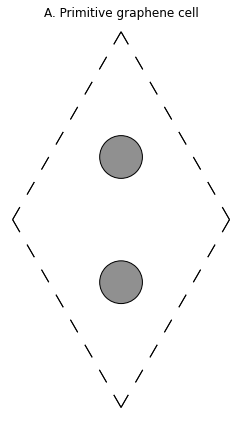

In [27]:
# A. Primitive graphene cell.
plot_structure(
    graphene,
    supercell=(1, 1, 1),
    title="A. Primitive graphene cell",
)
plt.show()


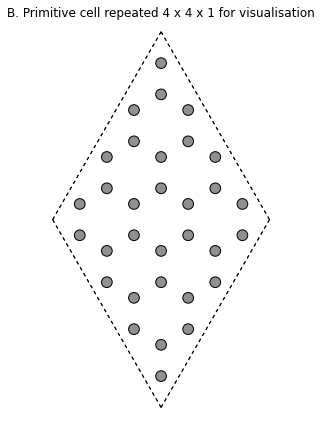

In [28]:
# B. Temporary repeated view of the primitive cell.
plot_structure(
    graphene,
    supercell=(4, 4, 1),
    title="B. Primitive cell repeated 4 x 4 x 1 for visualisation",
)
plt.show()


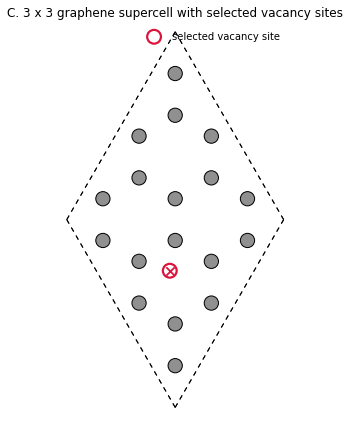

In [29]:
# C. Graphene supercell with the selected QUBO vacancy sites marked.
plot_structure(
    graphene_supercell,
    supercell=(1, 1, 1),
    vacancy_indices=vacancy_sites,
    title="C. 3 x 3 graphene supercell with selected vacancy sites",
)
plt.show()


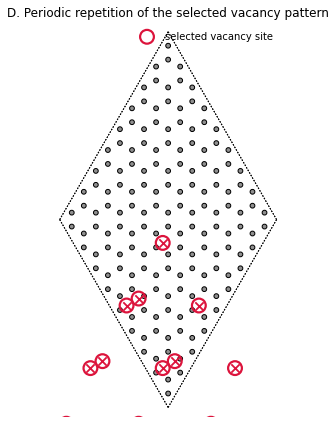

In [30]:
# D. The same vacancy pattern repeated periodically.
plot_structure(
    graphene_supercell,
    supercell=(3, 3, 1),
    vacancy_indices=vacancy_sites,
    title="D. Periodic repetition of the selected vacancy pattern",
)
plt.show()


The repeated plot shows why supercells matter. A vacancy does not represent one isolated defect in an infinite sheet; it represents a periodic array of defects. Larger supercells increase the distance between a defect and its periodic images, reducing artificial defect-defect interactions. This is a central consideration in atomistic modelling and is separate from the QUBO mapping itself.


## Optional challenge exercises

These are short extensions for participants who finish early. They are intentionally open-ended and do not require full solutions in the main workshop notebook.

### Challenge A: Site-dependent vacancy energies

Add local terms

$$
\sum_i h_i x_i,
$$

where some sites are more favourable vacancy sites than others. For example, choose a few sites with negative $h_i$ and check whether the sampler selects them under the fixed-vacancy-count constraint.

### Challenge B: Dopants instead of vacancies

Reinterpret $x_i=1$ as a dopant atom on site $i$, with a fixed dopant concentration. Which parts of the notebook can be reused unchanged, and which parts need a new physical interpretation?

### Challenge C: Convert the QUBO to Ising form

Convert from binary variables

$$
x_i \in \{0,1\}
$$

to spin variables

$$
s_i \in \{-1,1\}
$$

using

$$
x_i = \frac{1+s_i}{2}.
$$

Identify the resulting Ising fields and couplings for a small QUBO. How do constant energy offsets enter the conversion?


## 6. Summary

The mapping used in this notebook is:

1. Material configuration: possible vacancy sites in a graphene supercell.
2. Binary variables: $x_i = 1$ means site $i$ is vacant.
3. Graph model: nearest-neighbour adjacency matrix $A$ from the structure.
4. Objective: count broken nearest-neighbour bonds with a quadratic binary expression.
5. Constraint: enforce exactly $k$ vacancies using $\gamma(\sum_i x_i-k)^2$.
6. QUBO: combine objective and penalty terms in $Q$.
7. Sampler: use `neal` to sample candidate low-energy vacancy configurations.
8. Interpretation: convert the best bitstring back into selected material sites.

This is the same modelling pattern used in many QUBO applications: define variables, encode physics or graph logic as linear/quadratic terms, add penalties for constraints, sample, then postprocess candidate configurations.


## 7. Extensions

Possible extensions include:

- Dopant or alloy configurations, where variables select chemical species rather than vacancies.
- Pair interaction models with species-dependent coefficients.
- Cluster-expansion-like objectives with fitted interaction energies.
- Constraints on composition, sublattice occupancy, charge state, or symmetry classes.
- Quantum annealer runs, including embedding, chain strength selection, chain-break handling, and hardware-specific diagnostics.


WIP: The source notebooks sketch a coordination-based objective that distinguishes configurations with the same broken-bond count. The mathematical intent is to include information about neighbours of neighbours, but the implementation contains placeholders and needs scientific input before it should be presented as a finished model. Please check what physical quantity this term should approximate, what sign its coefficient should have, and how it should be validated against reference structures or calculations.


WIP: If the tutorial should include real D-Wave hardware execution, add the intended solver, account/project setup, chain-strength strategy, embedding diagnostics, and postprocessing rules. The current notebook keeps hardware access optional and uses `neal` for reproducible local execution.
